In [2]:
# pip install libraries

!pip install sentence-transformers faiss-cpu langchain
!pip install pypdf langchain_community
!pip install langchain-text-splitters

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.8/23.8 MB 61.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 333.7/333.7 kB 12.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.5/2.5 MB 79.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 45.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 65.0/65.0 kB 3.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 51.0/51.0 kB 3.0 MB/s eta 0:00:00
  Attempting uninstall: requests
    Found existing installation: requests 2.32.4
    Uninstalling requests-2.32.4:
      Successfully uninstalled requests-2.32.4
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires requests==2.32.4, but you have requests 2.33.0 which is incompatible.


In [3]:
# upload the document
from google.colab import files
uploaded = files.upload()

for filename in uploaded.keys():
  print("Uploaded:", filename)

Saving Microsoft 2025 Annual Report.pdf to Microsoft 2025 Annual Report (1).pdf
Uploaded: Microsoft 2025 Annual Report (1).pdf


In [4]:
# document ingestion pipeline

from langchain_community.document_loaders import PyPDFLoader

pdf_file = list(uploaded.keys())[0]
loader = PyPDFLoader(pdf_file)
documents = loader.load()
print("Number of pages loaded", len(documents))

Number of pages loaded 80


In [5]:
print(documents[0])

page_content='Home
Shareholder Letter
Financial Review
Business
General
Operating Segments
Human Capital Resources
Operations
Research & Development
Distribution, Sales & Marketing
Licensing Options
Government Regulation
Available Information
Discussion & Analysis
Market Risk
Income Statements
Balance Sheets
Cash Flows Statements
Stockholders' Equity
Notes
Accounting Policies
Earnings Per Share
Other Income (Expense), Net
Investments
Derivatives
Property and Equipment
Business Combinations
Goodwill
Intangible Assets
Debt
Income Taxes
Unearned Revenue
Leases
Contingencies
Stockholders' Equity
Accumulated Other Comprehensive Income (Loss)
Employee Stock and Savings Plans
Segment Information & Geo Data
Auditor's Report
Controls & Procedures
Directors & Officers
Investor Relations
Annual Report 2025
Continue to Shareholder Letter
Annual Report 2025
home  
3/27/26, 12:37 PM Microsoft 2025 Annual Report
https://www.microsoft.com/investor/reports/ar25/index.html 1/80' metadata={'producer': 'S

In [6]:
# chunking
from langchain_text_splitters import RecursiveCharacterTextSplitter

text_splitter = RecursiveCharacterTextSplitter(chunk_size = 500, chunk_overlap = 100)

chunks = text_splitter.split_documents(documents)

print("total chunk created:", len(chunks))

total chunk created: 594


In [7]:
print(chunks[0].page_content)

Home
Shareholder Letter
Financial Review
Business
General
Operating Segments
Human Capital Resources
Operations
Research & Development
Distribution, Sales & Marketing
Licensing Options
Government Regulation
Available Information
Discussion & Analysis
Market Risk
Income Statements
Balance Sheets
Cash Flows Statements
Stockholders' Equity
Notes
Accounting Policies
Earnings Per Share
Other Income (Expense), Net
Investments
Derivatives
Property and Equipment
Business Combinations
Goodwill


In [8]:
print(chunks[1].page_content)

Investments
Derivatives
Property and Equipment
Business Combinations
Goodwill
Intangible Assets
Debt
Income Taxes
Unearned Revenue
Leases
Contingencies
Stockholders' Equity
Accumulated Other Comprehensive Income (Loss)
Employee Stock and Savings Plans
Segment Information & Geo Data
Auditor's Report
Controls & Procedures
Directors & Officers
Investor Relations
Annual Report 2025
Continue to Shareholder Letter
Annual Report 2025
home  
3/27/26, 12:37 PM Microsoft 2025 Annual Report


In [9]:
# generate embedding from the chunk

import faiss
import numpy as np
from sentence_transformers import SentenceTransformer

model = SentenceTransformer('all-MiniLM-L6-v2')
embeddings = model.encode([chunk.page_content for chunk in chunks])
dimension = embeddings.shape[1]

index = faiss.IndexFlatL2(dimension)
index.add(np.array(embeddings))

print("Total vectors in ths index", index.ntotal)



/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Total vectors in ths index 594


In [10]:
print(dimension)

384


In [11]:
import matplotlib.pyplot as plt

def visualize_embedding(vector, chunk_text = None, max_text_chars = 500):
    vector = np.array(vector)

    v_min = vector.min()
    v_max = vector.max()

    # 3. Min-Max Normalization: Squishes the numbers between 0 and 1
    # This maps the "raw math" to "colors" that a human can see.
    normalized = (vector - v_min) / (v_max - v_min)

    # 4. Reshape to (1, N) so matplotlib sees it as a single row (a band)
    color_band = normalized.reshape(1, -1)

    if chunk_text is not None:
        print("--- Chunk Text ---")
        print(chunk_text[:max_text_chars])
        print("-" * 18)

    # 5. Plotting the "Heatmap" of the vector
    plt.figure(figsize=(12, 2))
    # 'viridis' goes from purple (low) to yellow (high)
    plt.imshow(color_band, aspect="auto", cmap="viridis")
    plt.yticks([]) # Hide the y-axis because there is only 1 row
    plt.xlabel(f"Embedding Dimensions ({len(vector)})")
    plt.title("Vector Visual Representation (Heatmap)")
    plt.colorbar(label="Normalized Value") # Useful to see the scale
    plt.show()


--- Chunk Text ---
always striving to create more value for our customers, our partners, and the world.
Striking this balance is hard work, and few companies over the years have been able to do it. To succeed, we
must continue to think in decades but execute in quarters, approaching each day with the humility and
curiosity required to continuously improve, while being guided by our bold vision for the future.
Financially, it was a year of record performance. Revenue was $281.7 billion, up 15 percent. Operating
------------------


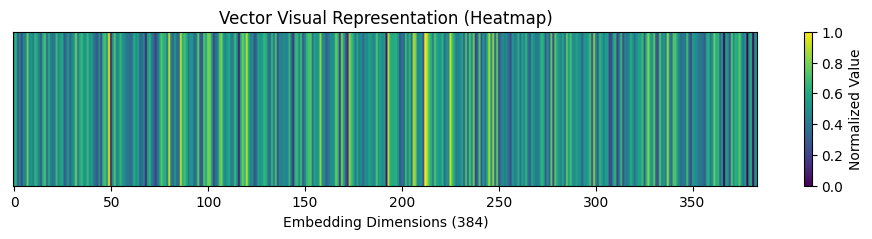

In [12]:
visualize_embedding(embeddings[5],chunks[5].page_content)

Enter your question: how much revenue increased from 2024 to 2025
--- Chunk Text ---
how much revenue increased from 2024 to 2025
------------------


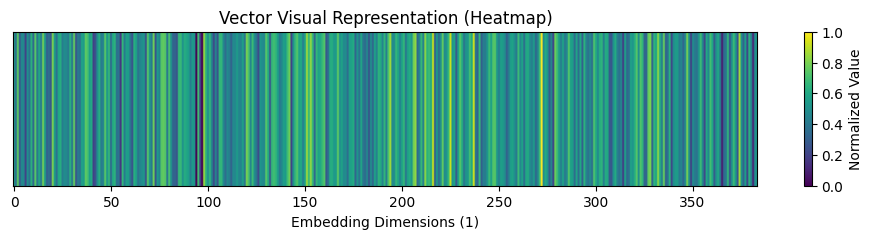

In [20]:
# retrieval

query = input("Enter your question: ")
query_embedding = model.encode([query])

visualize_embedding(query_embedding, query)

In [21]:
D, I = index.search(np.array(query_embedding), k=5)
retrieved_chunks = [chunks[i] for i in I[0]]

print("Top retrieved chunks: \n")
for chunk in retrieved_chunks:
  print(chunk.page_content)
  print("Page:", chunk.metadata["page"])
  print("------------------------------")


Top retrieved chunks: 

ended June 30, 2025 was primarily impacted by changes in the mix of our earnings and tax expenses
between the U.S. and foreign countries.
Our effective tax rate was lower than the U.S. federal statutory rate, primarily due to earnings taxed at lower
rates in foreign jurisdictions resulting from producing and distributing our products and services through
our foreign regional operations center in Ireland.
Page: 27
------------------------------
Fiscal Year 2025 Compared with Fiscal Year 2024
Sales and marketing expenses increased $1.2 billion or 5% driven by investments in commercial sales and
Gaming, including the impact of the Activision Blizzard acquisition.
General and Administrative
(In millions, except percentages) 2025 2024
Percentage
Change
General and administrative 7,223 7,609 (5)%
As a percent of revenue 3% 3% 0ppt
General and administrative expenses include payroll, employee benefits, stock-based compensation expense,
Page: 26
------------------------

In [22]:
# reranking

from sentence_transformers import CrossEncoder
reranker = CrossEncoder("cross-encoder/ms-marco-MiniLm-L6-v2")
pairs = [(query, chunk.page_content) for chunk in retrieved_chunks]
scores = reranker.predict(pairs)

ranked_chunks = sorted(zip(scores, retrieved_chunks),
                       key = lambda x: x[0],
                       reverse = True
                       )
print("After reranking: \n")
for score, chunk in ranked_chunks:
  print("scores:", score)
  print(chunk.page_content)
  print("Page number: ", chunk.metadata["page"])
  print("-----------------------------")

  # 34, 19, 20, 27, 36


Loading weights:   0%|          | 0/105 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: cross-encoder/ms-marco-MiniLm-L6-v2
Key                          | Status     |  | 
-----------------------------+------------+--+-
bert.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


After reranking: 

scores: 7.3121796
Fiscal Year 2025 Compared with Fiscal Year 2024
Sales and marketing expenses increased $1.2 billion or 5% driven by investments in commercial sales and
Gaming, including the impact of the Activision Blizzard acquisition.
General and Administrative
(In millions, except percentages) 2025 2024
Percentage
Change
General and administrative 7,223 7,609 (5)%
As a percent of revenue 3% 3% 0ppt
General and administrative expenses include payroll, employee benefits, stock-based compensation expense,
Page number:  26
-----------------------------
scores: 7.041507
announced in January 2025.
LinkedIn revenue increased $1.4 billion or 9% with growth across all lines of business.
Dynamics products and cloud services revenue increased $996 million or 15% driven by growth in
Dynamics 365, offset in part by a decline in Dynamics on-premises products. Dynamics 365 revenue
grew 19% with growth across all workloads.
Annual Report 2025
home  
3/27/26, 12:37 PM Microsoft 

In [16]:
# combine reranked chunk with context

top_chunks = [chunk.page_content for _,chunk in ranked_chunks[:3]]
context = "\n\n".join(top_chunks)
print(context)

related to compensating employees; supporting and investing in our cloud-based services, including
datacenter operations; designing, manufacturing, marketing, and selling our other products and services;
and income taxes.
Highlights from fiscal year 2025 compared with fiscal year 2024 included:
Microsoft Cloud revenue increased 23% to $168.9 billion.
Annual Report 2025
home  
3/27/26, 12:37 PM Microsoft 2025 Annual Report
https://www.microsoft.com/investor/reports/ar25/index.html 20/80

Year Ended June 30, 2025 2024 2023
Revenue:
Product 63,946 64,773 64,699
Service and other 217,778 180,349 147,216
Annual Report 2025
home  
3/27/26, 12:37 PM Microsoft 2025 Annual Report
https://www.microsoft.com/investor/reports/ar25/index.html 35/80

Long-term unearned revenue 2,710 2,602
Annual Report 2025
home  
3/27/26, 12:37 PM Microsoft 2025 Annual Report
https://www.microsoft.com/investor/reports/ar25/index.html 37/80


In [17]:
!pip install -q -U google-genai

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.3/52.3 kB 2.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 750.9/750.9 kB 24.0 MB/s eta 0:00:00


In [25]:
from google.genai import Client
from google.colab import userdata
import numpy as np

# 1. Initialize the Client
client = Client(api_key=userdata.get('GOOGLE_API_KEY'))

def ask_bot():
    print("--- 🤖 RAG Chatbot Started! Type 'exit' to stop. ---")

    while True:
        # Get user input
        query = input("\n👤 You: ")

        if query.lower() in ['exit', 'quit', 'bye']:
            print("👋 Goodbye!")
            break

        # 2. RETRIEVAL STEP
        # We turn your question into a vector using the same model we used for chunks
        query_vector = model.encode([query])

        # Search the FAISS index for the top 3 most relevant chunks
        # D is distance, I is the index/ID of the chunk
        D, I = index.search(np.array(query_vector), k=3)

        # Pull the actual text from your 'chunks' list using the IDs found by FAISS
        retrieved_chunks = [chunks[i].page_content for i in I[0]]
        context = "\n\n".join(retrieved_chunks)

        # 3. GENERATION STEP (Gemini)
        prompt = f"""
        Answer the question using the context below.
        Context:
        {context}

        Question:
        {query}

        Provide a concise answer.
        If you don't find the info in the context, do not guess.
        Just say that the info is not found in the document.
        """

        try:
            # Note: Using gemini-1.5-flash as it's the stable production standard
            response = client.models.generate_content(
                model="gemini-2.5-flash",
                contents=prompt
            )

            print(f"\n🤖 Bot: {response.text}")

        except Exception as e:
            print(f"❌ Error: {e}")

# Run the chatbot
ask_bot()

--- 🤖 RAG Chatbot Started! Type 'exit' to stop. ---

👤 You: tell the amount of loss happened in 2025

🤖 Bot: A loss of $103 million from reclassification adjustments for (gains) losses included in other income (expense), net, happened in 2025.

👤 You: exit
👋 Goodbye!
